# Picking out Hummed and Whistled Songs: Aggregated and Sequential Audio Representations

---

### Overview

Given a short recording of a person humming or whistling, can a machine learning model identify
which of eight songs is being performed? This project addresses that audio
classification problem using the `MLEndHWII_Sample_800` subset of the MLEnd Hums and Whistles II
dataset (800 recordings, contributed by multiple participants, in both hummed and whistled form).

The following two hypotheses are tested: that a song can be recognised solely from *aggregated spectral
statistics* (timbre and average tonality), discarding the order; and that it can be recognised from the
*temporal sequence*, meaning the order of spectral frames (melody). The first is represented by **logistic regression**, **SVM**, and **random forest**, trained on summary statistics of
MFCC, chroma, spectral-contrast and delta features; the second by an **LSTM** and a **2D CNN** trained on
frame-level MFCC sequences. 

The choice of model and feature-set is selected on the training partition using participant-disjoint cross validation, and the held-out test partition
is used once. The participant-disjoint protocol is a design choice. As there are multiple recordings for each participant, a random file-level split would allow the same voice to be present in both partitions, artificially increasing accuracy and biasing the results towards speaker recognition. Results, chance-level comparisons and per-class behaviour are reported in
Section 6. 

The selected model (a tuned random forest on aggregated
features) classified **31.9%** of 160 held-out recordings from unseen
performers correctly (95% CI [24.7%, 39.7%]) against a 12.5% chance level, and the analysis attributes
that signal to pitch-class (chroma) descriptors rather than to timbre. The sequence models performed
worse than the classical ones at this sample size. Two recordings in three are still misclassified, so
this is a result about what is learnable from 800 recordings, not a usable system; the limitations of
a dataset of this size are stated explicitly in Section 7.1.

### How to read this notebook

The section numbering follows the structure prescribed in the mini-project submission instructions:
Author, Problem formulation, Methodology, Implemented ML prediction pipelines (with transformation,
model and ensemble stages), Dataset, Experiments and results, Conclusions, References. Sections 3
and 4 describe the approach before any code is run; Section 5 builds and explores the datasets;
Section 6 carries out the experiments and analyses them.

The notebook is designed to run top-to-bottom from a clean kernel, and the evaluation protocol is
fixed in Section 3 *before* any model is fitted, so that no design decision can be influenced by a
test result.

**Data requirement.** The notebook expects the audio files in the directory given by `DATA_DIR` in
Section 5.1. Nothing outside that directory is required, and no cell depends on state produced
outside this notebook.

## 1 Author

**Name:** Cipriano Gertrudes Sebastiao

---

## 2 Problem formulation

### 2.1 Task and motivation

Retrieval of a song from a sung, hummed or whistled fragment is called query-by-humming. Query-by-humming is a challenging problem because a hum is a very lossy and subjective reconstruction of the melody being sung, hummed or whistled. The singer may transpose the melody, alter the speed, add and remove notes, breathe loudly while singing the phrase, and record with an arbitrary recording device. Therefore, a good model needs to be invariant to the singer and recording environment, yet sensitive to the aspects of the song that identify it.

### 2.2 Machine learning formulation

The problem is formulated as **single-label multi-class supervised classification**.

- **Input** $(x)$: one monophonic audio recording of a person humming or whistling one song,
  truncated or zero-padded to a fixed 10-second window.
- **Output** $(y \in \{1,\dots,8\})$: the identity of the song performed, from the eight song classes
  present in this subset.
- **Learned object**: a mapping $(f)$ from a fixed-dimensional representation of the recording to a
  song label, chosen to minimise expected misclassification on *recordings from performers not seen
  during training*.

### 2.3 Why the problem is interesting

This task is inherently difficult which is what makes it informative. A hum removes almost everything an audio-fingerprinting system would use (original instrument timbres, harmony, production) but keeps a roughly human recreated melodic contour. Thus, the only thing we must identify is a one-off trait that two people humming the same tune will have but that is not changed by the difference between them. The project is consequently as much a study of
*which representation carries song identity* as of which classifier is strongest.

## 3 Methodology

### 3.1 Premise

The target population for deployment are *new users*, so the relevant estimate relates to the generalisation to unseen **performers**. This single assumption is the most substantial reasoning decision in the project: it constrains how the data can be split for a valid evaluation. In one scenario, a model could obtain an excellent score by correctly picking out the individual humming, rather than identifying the melody that they are humming.

### 3.2 Training task

The training task is to fit a classifier that maps a fixed-dimensional representation of a
10-second recording to one of eight song labels, minimising cross-entropy (networks) or the
equivalent regularised objective of each classical model. Only the **development** partition is used
for fitting, and every preprocessing step that learns from data (scaling, channel normalisation) is
fitted inside the resampling loop on training folds alone, so that no statistic from held-out audio
reaches the model.

### 3.3 Validation task

The validation task is to estimate, from development data only, how each candidate would perform on
a performer it has never heard, and to use those estimates to choose the feature representation, the
model family, the hyperparameters and the stopping epoch.

This is implemented as **stratified, participant-disjoint 5-fold cross-validation**
(`StratifiedGroupKFold`, grouping on participant): each fold holds out whole participants while
keeping the song distribution as even as the grouping allows. The neural networks, which are too
expensive to cross-validate five times within this project's compute budget, instead use a single
inner participant-disjoint validation fold drawn from the same development data; this asymmetry is
stated again wherever their scores are compared.

The **test** partition is held out from the start and read exactly once, in Section 6.9, after the
single final model has been chosen. It informs no decision of any kind.

### 3.4 How performance is defined

- **Accuracy**, directly interpretable against the chance level of $(1/8 = 12.5\%)$ under a balanced
  distribution, and the quantity a user of a query-by-humming system actually experiences.
- **Macro-averaged F1**, which weights all eight songs equally and so exposes a model that achieves
  reasonable accuracy by favouring a few easy classes.
- **Confusion matrix**, in raw counts and row-normalised form, to show *which* songs are confused
  rather than only how often.

Neither headline metric is meaningful in isolation, so every figure is reported alongside computed
trivial baselines (Section 6.1), fold-to-fold standard deviations, and — for the final estimate — a
95% confidence interval and a one-sided binomial test against chance, because a point estimate from
a test partition of this size carries several points of sampling error.

### 3.5 Supporting tasks

Three further tasks support the main one: an integrity audit of the audio and its filename-encoded
labels (Section 5.3); exploratory analysis to establish class balance and the depth of participant
nesting, which is what justifies the grouped protocol (Sections 5.5–5.8); and an interpretation
stage using grouped permutation importance and error analysis by performance style (Sections
6.11–6.12).

## 4 Implemented ML prediction pipelines

Every pipeline explored here has the same input and output and differs only in its internal stages:

- **Input:** one mono WAV recording of a hum or whistle, resampled to 22.05 kHz and fixed to a
  10-second window by truncation or zero-padding.
- **Output:** one of eight song labels.

Two pipeline architectures are explored, corresponding to the two competing hypotheses about where
song identity resides.

**Pipeline 1 — aggregated (order-discarding).**
`audio (220500 samples)` → frame-level features `(431 frames x 40)` → summary statistics over time
`(20 to 118 features)` → `StandardScaler` → classical classifier → label.

**Pipeline 2 — sequential (order-preserving).**
`audio (220500 samples)` → frame-level features `(431 frames x 40)` → per-channel standardisation
→ recurrent or convolutional network → label.

### 4.1 Transformation stage

The raw waveform is far too high-dimensional to model directly (220,500 samples per clip against a
few hundred training examples), so all pipelines begin by reducing each recording to a
time–frequency description.

**Frame-level features.** 20 MFCCs are computed per short frame, capturing the coarse spectral
envelope, together with their first temporal derivatives (deltas), which describe how that envelope
changes — the closest cheap proxy for melodic movement. This yields a `431 x 40` matrix per
recording. MFCCs are chosen because they are a compact, decorrelated summary of the spectrum that is
standard in speech and music tasks; the delta channels are added because a hum's information is in
its changes, not its steady state.

**Aggregation into a fixed vector (Pipeline 1).** Time is collapsed by taking the mean and standard
deviation of each channel, and adding chroma (pitch-class energy) and spectral-contrast statistics.
This deliberately *destroys temporal order*, which makes it a clean test of the timbre-versus-melody
question: whatever such a model achieves is achievable without knowing the order of the notes.
Chroma is included precisely because it is the descriptor most closely tied to pitch content and
therefore the most plausible carrier of song identity that survives aggregation. Four nested feature
sets (20, 40, 80 and 118 dimensions) are built so that the contribution of each family can be
attributed rather than assumed.

**Standardisation.** Feature scales differ by orders of magnitude, which harms distance- and
gradient-based learners. Scaling is therefore part of the pipeline object, refitted on the training
folds inside every cross-validation split, never on the full dataset.

### 4.2 Model stage

Four model families are explored, chosen to span the hypothesis space rather than to maximise a
leaderboard:

- **Multinomial logistic regression** — a linear, well-regularised reference that establishes how
  much of the problem is linearly separable in the aggregated space.
- **SVM with an RBF kernel** — effective in the regime this project sits in, many features and few
  samples, and able to form non-linear boundaries without a large parameter count.
- **Random forest** — non-linear, robust to feature scaling and mixed feature families, and it
  exposes a usable importance signal for the interpretation stage.
- **LSTM and 2D CNN** on frame-level sequences — the only candidates that can exploit temporal
  order. The LSTM consumes frames in order and maintains state; the CNN treats the MFCC matrix as an
  image and detects local time–frequency motifs wherever they occur, giving partial invariance to
  *when* a phrase is hummed.

### 4.3 Ensemble stage

Two forms of ensembling are present, and it is worth separating them because they are often
conflated.

**Implicit ensembling inside the random forest.** A random forest is itself an ensemble: it bags
many decision trees on bootstrap resamples with a random feature subset at each split, and averages
their votes. Its benefit here is variance reduction, which is the dominant error term with a few
hundred training examples.

**An explicit soft-voting ensemble** (Section 6.6) combines the tuned SVM, the tuned random forest
and regularised logistic regression by averaging their predicted class probabilities. The rationale
is that these three make errors for different reasons — a kernel boundary, axis-aligned partitions
and a linear boundary rarely fail on the same recordings — and averaging calibrated probabilities
can therefore recover accuracy that no single member reaches. It is a candidate like any other: it
is scored by the same participant-disjoint cross-validation and is only used for the final
evaluation if it wins on development data. Its cost is interpretability, which is why the
interpretation stage in Section 6.11 is run on a single tree-based model.

## 5 Dataset

This section builds the datasets described in Sections 3 and 4, audits and explores them, and then
creates the training and test partitions.

### 5.1 Environment, configuration and reproducibility

All tunable quantities are centralised in one configuration cell so that every downstream result is
traceable to an explicit choice rather than to a value buried in a function body. Random seeds are
fixed for Python, NumPy and TensorFlow, and TensorFlow operations are placed in deterministic mode,
so that reported numbers are reproducible on the same hardware and library versions. Library
versions are printed because audio and deep-learning results are sensitive to them.

Package installation is deliberately *not* performed inside the notebook; dependencies are pinned in
the accompanying `requirements.txt`. Installation commands mixed into an analysis notebook mutate the
environment at run time, produce large amounts of irrelevant output, and make the recorded results
impossible to attribute to a known environment.

In [1]:
import hashlib
import json
import os
import platform
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import sklearn
import tensorflow as tf

from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (StratifiedGroupKFold, GridSearchCV,
                                     cross_validate)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)
from scipy.stats import binomtest

print("python      ", platform.python_version())
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("librosa     ", librosa.__version__)
print("tensorflow  ", tf.__version__)

2026-09-21 14:44:23.294398: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-21 14:44:23.339917: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


python       3.11.15
numpy        1.26.4
pandas       2.2.2
scikit-learn 1.5.2
librosa      0.11.0
tensorflow   2.17.0


In [2]:
SEED = 42
DATA_DIR = Path("Datasets/MLEndHWII_sample_800")
CACHE_DIR = Path("artifacts")
FIG_DIR = CACHE_DIR / "figures"

SR = 22050                 # analysis sample rate; see Section 5.4 for justification
CLIP_SECONDS = 10.0
N_MFCC = 20
MAX_FRAMES = 431           # 10 s at hop_length=512 and sr=22050
TEST_FRACTION = 0.2        # realised as one fold of a 5-fold grouped split
N_CV_FOLDS = 5
NN_MAX_EPOCHS = 80
NN_BATCH_SIZE = 32

CACHE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:                      # not available in older TF builds
    print("Deterministic op mode unavailable:", exc)

get_ipython().run_line_magic("matplotlib", "inline")

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160,
                     "axes.titleweight": "bold", "figure.autolayout": True})

if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Audio directory not found: {DATA_DIR.resolve()}\n"
        "Set DATA_DIR to the folder containing the MLEndHWII_Sample_800 .wav files."
    )
print("Audio directory:", DATA_DIR.resolve())

Audio directory: /home/user/workspace/Datasets/MLEndHWII_sample_800


Warnings are left enabled. Audio decoding and `scikit-learn` emit warnings that carry real
diagnostic information (for example, deprecated argument names or classes missing from a
cross-validation fold), and suppressing them globally hides exactly the failures this project needs
to detect. Only the specific, known-benign `librosa`/`numba` performance warnings are filtered.

In [3]:
warnings.filterwarnings("ignore", category=UserWarning, module="librosa")

### 5.2 Source and labelling scheme

The data is the `MLEndHWII_Sample_800` subset of the MLEnd Hums and Whistles II dataset, an 800-file
sample of a crowdsourced collection in which contributors recorded themselves humming and whistling
well-known songs. Labels are not supplied in a separate table; they are encoded in the filenames,
which follow the pattern

```
S<participant>_<interpretation>_<take>_<song>.wav        e.g.  S100_hum_2_Married.wav
```

Four fields are therefore recoverable, and all four are used in this project:

| Field | Role in this project |
|---|---|
| `participant` | **grouping variable** for all splits and cross-validation (Section 5.9) |
| `interpretation` | `hum` or `whistle`; used for stratification checks and error analysis (Section 6.12) |
| `take` | repetition index; used to detect near-duplicate recordings |
| `song` | the **target variable** |

Rather than splitting on `_` and trusting the last token, the filename is matched against an explicit
regular expression and every file that fails to match is reported. Silent parsing failures on a
filename-derived target are the single most damaging class of bug available in this dataset: a
mislabelled subset would corrupt every result downstream while leaving all outputs looking entirely
plausible.

In [4]:
FILENAME_RE = re.compile(
    r"^(?P<participant>S\d+)_(?P<interpretation>hum|whistle)_(?P<take>\d+)_(?P<song>[A-Za-z0-9]+)\.wav$",
    re.IGNORECASE,
)


def build_inventory(directory: Path) -> tuple[pd.DataFrame, list[str]]:
    '''Parse participant / interpretation / take / song out of every .wav filename.'''
    rows, unparsed = [], []
    for path in sorted(directory.glob("*.wav")):
        match = FILENAME_RE.match(path.name)
        if match is None:
            unparsed.append(path.name)
            continue
        record = match.groupdict()
        record["interpretation"] = record["interpretation"].lower()
        record["take"] = int(record["take"])
        record["filename"] = path.name
        record["path"] = str(path)
        rows.append(record)
    return pd.DataFrame(rows), unparsed


inventory, unparsed_files = build_inventory(DATA_DIR)

print(f"Files parsed successfully : {len(inventory)}")
print(f"Files that failed parsing : {len(unparsed_files)}")
if unparsed_files:
    print("  ->", unparsed_files[:10])
print(f"Distinct songs            : {inventory['song'].nunique()}")
print(f"Distinct participants     : {inventory['participant'].nunique()}")
print(f"Interpretation types      : {sorted(inventory['interpretation'].unique())}")
inventory.head()

Files parsed successfully : 800
Files that failed parsing : 0
Distinct songs            : 8
Distinct participants     : 187
Interpretation types      : ['hum', 'whistle']


,participant,interpretation,take,song,filename,path
0,S100,hum,2,Married,S100_hum_2_Married.wav,Datasets/MLEndHWII_sample_800/S100_hum_2_Marri...
1,S100,whistle,2,Friend,S100_whistle_2_Friend.wav,Datasets/MLEndHWII_sample_800/S100_whistle_2_F...
2,S100,whistle,2,Happy,S100_whistle_2_Happy.wav,Datasets/MLEndHWII_sample_800/S100_whistle_2_H...
3,S100,whistle,2,RememberMe,S100_whistle_2_RememberMe.wav,Datasets/MLEndHWII_sample_800/S100_whistle_2_R...
4,S101,hum,1,Married,S101_hum_1_Married.wav,Datasets/MLEndHWII_sample_800/S101_hum_1_Marri...


### 5.3 Structural integrity checks

Before any feature is computed, the dataset is audited for the defects that would otherwise be
absorbed silently into the model: unreadable or zero-length files, inconsistent sample rates or
channel counts, recordings much shorter than the assumed analysis window, and byte-identical
duplicates. The duplicate check is not cosmetic — an identical recording appearing on both sides of
a split is a direct form of leakage, and it is cheap to rule out with a content hash.

In [5]:
def audit_audio(inventory: pd.DataFrame) -> pd.DataFrame:
    records = []
    for row in inventory.itertuples(index=False):
        entry = {"filename": row.filename}
        try:
            info = sf.info(row.path)
            entry.update(duration_s=info.duration, sample_rate=info.samplerate,
                         channels=info.channels, readable=True, error="")
        except Exception as exc:
            entry.update(duration_s=np.nan, sample_rate=np.nan, channels=np.nan,
                         readable=False, error=f"{type(exc).__name__}: {exc}")
        with open(row.path, "rb") as handle:
            entry["content_md5"] = hashlib.md5(handle.read()).hexdigest()
        records.append(entry)
    return pd.DataFrame(records)


audit = audit_audio(inventory)
inventory = inventory.merge(audit, on="filename", validate="one_to_one")

duplicate_hashes = (inventory.groupby("content_md5")["filename"]
                             .agg(list).loc[lambda s: s.str.len() > 1])

print(f"Unreadable files              : {(~inventory['readable']).sum()}")
print(f"Missing values in inventory   : {int(inventory.isna().sum().sum())}")
print(f"Duplicate filenames           : {int(inventory['filename'].duplicated().sum())}")
print(f"Byte-identical duplicate sets : {len(duplicate_hashes)}")
if len(duplicate_hashes):
    print(duplicate_hashes.head(10).to_string())
print(f"Sample rates present          : {sorted(inventory['sample_rate'].dropna().unique())}")
print(f"Channel counts present        : {sorted(inventory['channels'].dropna().unique())}")
print("\nDuration (seconds) summary:")
print(inventory["duration_s"].describe().round(2).to_string())
print(f"\nRecordings shorter than {CLIP_SECONDS:.0f}s : "
      f"{int((inventory['duration_s'] < CLIP_SECONDS).sum())}")

Unreadable files              : 0
Missing values in inventory   : 0
Duplicate filenames           : 0
Byte-identical duplicate sets : 0
Sample rates present          : [44100, 48000]
Channel counts present        : [1, 2]

Duration (seconds) summary:
count    800.00
mean      21.47
std        5.79
min       10.62
25%       17.42
50%       19.58
75%       23.66
max       39.09

Recordings shorter than 10s : 0


### 5.4 Consequences for the representation

Two decisions follow directly from the audit and are applied identically to every recording.

**Analysis sample rate.** The recordings are read at an explicit 22.05 kHz rather than at their
native rate. Hummed and whistled pitch content lies well below the 11 kHz Nyquist limit this
implies, so no information relevant to the task is discarded, while fixing the rate guarantees that
every file yields the same number of analysis frames and removes an uncontrolled source of variation
between recordings made on different devices. Stating the rate explicitly also avoids an easy
documentation error: `librosa.load` resamples to 22.05 kHz by default, so a notebook that reports
"44.1 kHz waveforms, 441,000 samples" while calling the default is describing something it never
computed.

**Fixed-length window.** Clips are truncated or zero-padded to exactly 10 seconds. Any
duration-dependent representation would otherwise let clip length act as a spurious cue, and both
sequence models require a fixed input length.

The purpose of this section is not to display the data but to answer four specific questions whose
answers change later modelling decisions: is the target balanced, how is the data nested inside
participants, do the two interpretation styles behave like one population or two, and is there any
visible class structure in the aggregated feature space at all.

### 5.5 Is the target variable balanced?

This determines whether accuracy is interpretable against a flat \(1/8\) chance level, whether macro
F1 will diverge from accuracy, and whether class weighting is required.

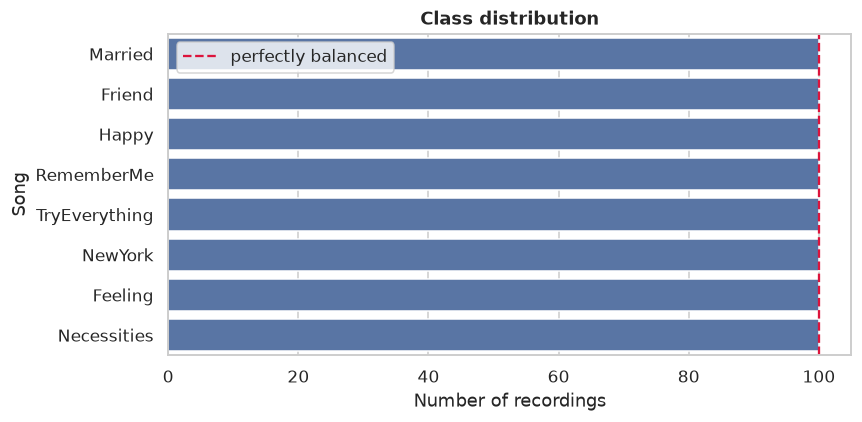

song
Married          100
Friend           100
Happy            100
RememberMe       100
TryEverything    100
NewYork          100
Feeling          100
Necessities      100

Majority-class share : 0.125
Minority-class share : 0.125
Imbalance ratio      : 1.00


In [6]:
song_counts = inventory["song"].value_counts().sort_values(ascending=False)
class_share = song_counts / len(inventory)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=song_counts.values, y=song_counts.index, ax=ax, color="#4C72B0")
ax.axvline(len(inventory) / inventory["song"].nunique(), color="crimson",
           linestyle="--", label="perfectly balanced")
ax.set(xlabel="Number of recordings", ylabel="Song", title="Class distribution")
ax.legend()
plt.show()

print(song_counts.to_string())
print(f"\nMajority-class share : {class_share.max():.3f}")
print(f"Minority-class share : {class_share.min():.3f}")
print(f"Imbalance ratio      : {song_counts.max() / song_counts.min():.2f}")

### 5.6 How is the data nested within participants?

Each contributor recorded several songs, in one or both interpretation styles, sometimes more than
once. The recordings are therefore **not independent**: files from one participant share a vocal
tract, a microphone and a room. The two plots below quantify how many recordings a single
participant can contribute and how many participants each song draws on. The first quantity bounds
how much a model could gain from recognising voices instead of songs; the second bounds how much
performer variation the model can possibly learn per class. Together they are the evidence for the
participant-disjoint protocol adopted in Section 5.9.

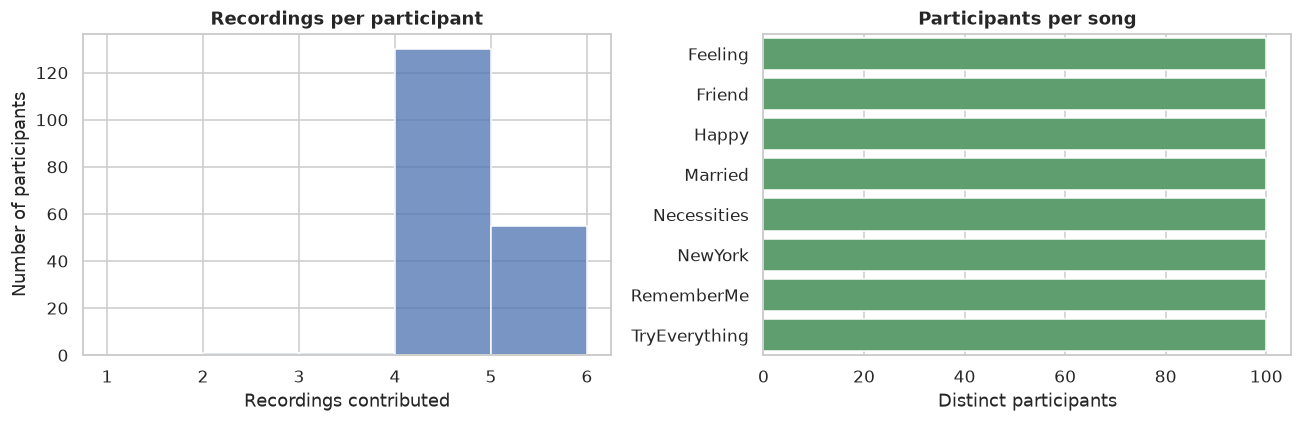

Participants                         : 187
Recordings per participant  (median) : 4
Recordings per participant  (max)    : 5
Participants contributing >1 file    : 187
Share of files from such participants: 100.00%


In [7]:
per_participant = inventory.groupby("participant").size()
participants_per_song = inventory.groupby("song")["participant"].nunique().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(per_participant, bins=range(1, per_participant.max() + 2),
             ax=axes[0], color="#4C72B0")
axes[0].set(xlabel="Recordings contributed", ylabel="Number of participants",
            title="Recordings per participant")
sns.barplot(x=participants_per_song.values, y=participants_per_song.index,
            ax=axes[1], color="#55A868")
axes[1].set(xlabel="Distinct participants", ylabel="", title="Participants per song")
plt.show()

print(f"Participants                         : {inventory['participant'].nunique()}")
print(f"Recordings per participant  (median) : {per_participant.median():.0f}")
print(f"Recordings per participant  (max)    : {per_participant.max()}")
print(f"Participants contributing >1 file    : {(per_participant > 1).sum()}")
print(f"Share of files from such participants: "
      f"{per_participant[per_participant > 1].sum() / len(inventory):.2%}")

The proportion of recordings belonging to participants who contributed more than one file is the
size of the leakage channel that a naive random file-level split would open. Every one of those
files could have a sibling from the same voice on the other side of the split.

### 5.7 Do hums and whistles form one population or two?

Hums and whistles differ in their acoustic mechanism: whistling is close to a pure tone with energy
concentrated in a narrow high band, while humming is a low-frequency, harmonically rich signal. If
the two styles are distributed unevenly across songs, a model can partially identify a song by
identifying its dominant recording style, which is a real but unintended shortcut worth knowing
about before interpreting any confusion matrix.

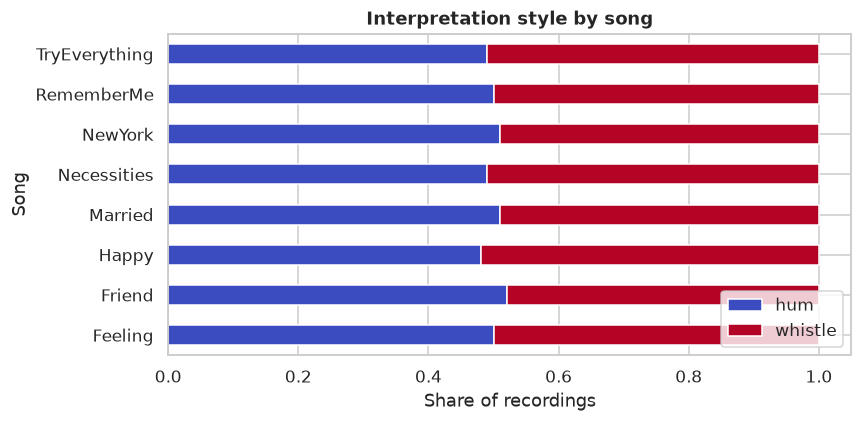

interpretation  hum  whistle
song                        
Feeling          50       50
Friend           52       48
Happy            48       52
Married          51       49
Necessities      49       51
NewYork          51       49
RememberMe       50       50
TryEverything    49       51

Overall style balance:
interpretation
hum        0.5
whistle    0.5


In [8]:
style_by_song = pd.crosstab(inventory["song"], inventory["interpretation"])
style_share = style_by_song.div(style_by_song.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
style_share.plot(kind="barh", stacked=True, ax=ax, colormap="coolwarm")
ax.set(xlabel="Share of recordings", ylabel="Song",
       title="Interpretation style by song")
ax.legend(title="", loc="lower right")
plt.show()

print(style_by_song.to_string())
print("\nOverall style balance:")
print((inventory['interpretation'].value_counts(normalize=True)).round(3).to_string())

### 5.8 What does a single recording look like?

One hummed and one whistled example are shown as a waveform and as a log-mel spectrogram. The point
of the comparison is to make the modelling hypotheses concrete: the spectrogram of a whistle shows a
narrow, clearly traceable pitch contour over time, whereas the hum shows broad harmonic stacks. A
representation that averages over the time axis keeps the vertical structure and discards the
contour; a sequence or image model keeps both. These are exactly the two hypotheses compared in
Sections 6–7.

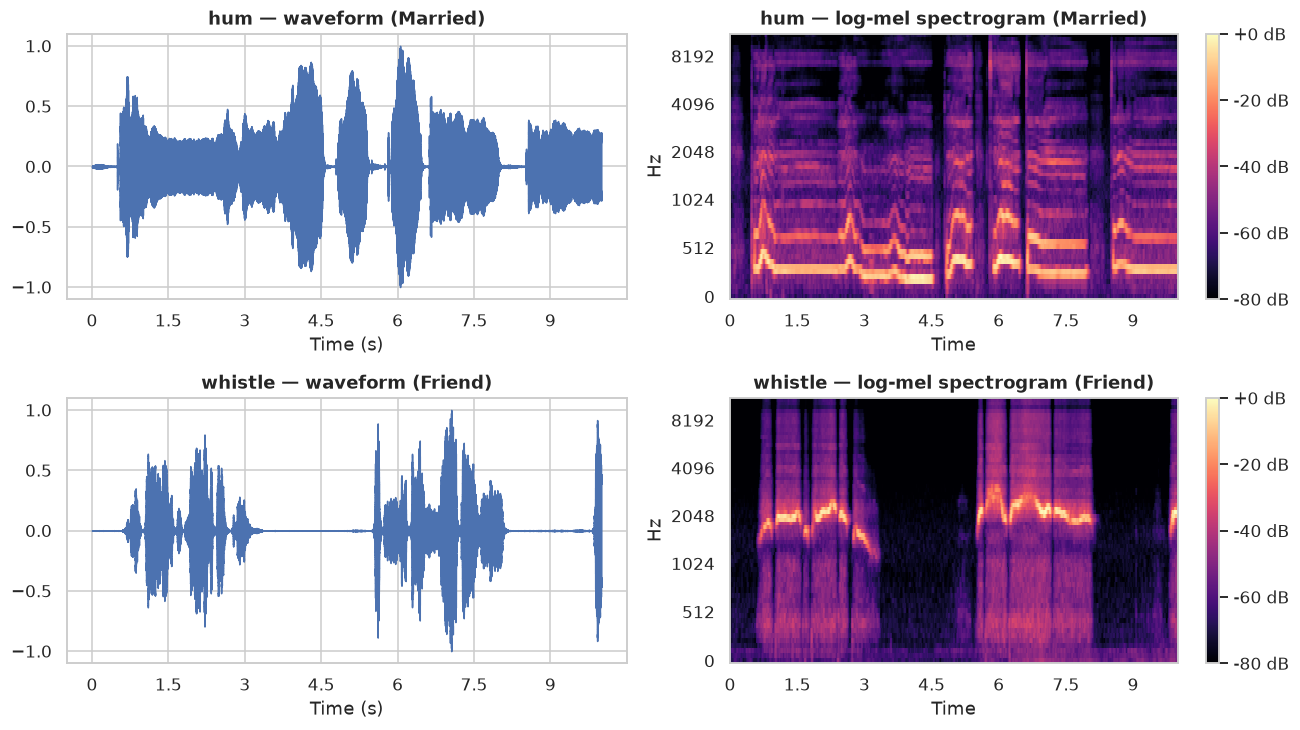

In [9]:
def load_clip(path: str) -> np.ndarray:
    '''Load a mono clip at SR, peak-normalise it, and fix its length to CLIP_SECONDS.'''
    audio, _ = librosa.load(path, sr=SR, mono=True, duration=CLIP_SECONDS)
    peak = np.max(np.abs(audio)) if audio.size else 0.0
    if peak > 0:
        audio = audio / peak                    # remove per-device gain differences
    target = int(round(SR * CLIP_SECONDS))
    if audio.size < target:
        audio = np.pad(audio, (0, target - audio.size))
    return audio[:target]


examples = {}
for style in ["hum", "whistle"]:
    subset = inventory[inventory["interpretation"] == style]
    if len(subset):
        examples[style] = subset.iloc[0]

fig, axes = plt.subplots(len(examples), 2, figsize=(12, 3.4 * len(examples)))
axes = np.atleast_2d(axes)
for row, (style, meta) in enumerate(examples.items()):
    audio = load_clip(meta["path"])
    librosa.display.waveshow(audio, sr=SR, ax=axes[row, 0], color="#4C72B0")
    axes[row, 0].set(title=f"{style} — waveform ({meta['song']})", xlabel="Time (s)")

    mel_db = librosa.power_to_db(
        librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64), ref=np.max)
    image = librosa.display.specshow(mel_db, sr=SR, x_axis="time", y_axis="mel",
                                     ax=axes[row, 1], cmap="magma")
    axes[row, 1].set(title=f"{style} — log-mel spectrogram ({meta['song']})")
    fig.colorbar(image, ax=axes[row, 1], format="%+2.0f dB")
plt.show()

### 5.9 Building the training and test partitions

The dataset is partitioned once into a **development** partition (used for all feature-set choices,
model choices and hyperparameter searches) and a **test** partition (used once, in Section 6.9). Two
properties are enforced simultaneously:

- **Participant-disjointness.** No participant appears in both partitions. Section 5.6 showed that
  participants contribute multiple recordings, so a random file-level split would place recordings of
  the same voice on both sides. A model could then score well by recognising *who is humming* and
  exploiting the correlation between performer and song within the dataset — an ability that
  transfers to no new user. This is the difference between measuring song recognition and measuring
  performer recognition, and it is not detectable from the accuracy number alone.
- **Class stratification.** The song distribution is preserved as closely as the grouping constraint
  allows, so that no class is absent or severely under-represented in either partition.

`StratifiedGroupKFold` satisfies both: it forms folds that are group-disjoint while balancing the
label distribution. The first fold of a five-fold partition is taken as the test set, giving the
intended 80/20 ratio. The identical splitter, restricted to the development partition, provides the
cross-validation folds used for every subsequent decision, so the model-selection procedure and the
final evaluation obey the same notion of generalisation.

In [10]:
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(inventory["song"])
groups_all = inventory["participant"].to_numpy()
CLASS_NAMES = list(label_encoder.classes_)
N_CLASSES = len(CLASS_NAMES)

splitter = StratifiedGroupKFold(n_splits=int(round(1 / TEST_FRACTION)),
                                shuffle=True, random_state=SEED)
dev_idx, test_idx = next(splitter.split(inventory, y_all, groups=groups_all))

inventory["partition"] = "development"
inventory.iloc[test_idx, inventory.columns.get_loc("partition")] = "test"

y_dev, y_test = y_all[dev_idx], y_all[test_idx]
groups_dev = groups_all[dev_idx]

print(f"Classes ({N_CLASSES}): {CLASS_NAMES}")
print(f"Development recordings : {len(dev_idx)}  ({len(dev_idx)/len(inventory):.1%})")
print(f"Test recordings        : {len(test_idx)}  ({len(test_idx)/len(inventory):.1%})")
print(f"Development participants: {inventory.loc[inventory.partition=='development','participant'].nunique()}")
print(f"Test participants       : {inventory.loc[inventory.partition=='test','participant'].nunique()}")
print("\nClass distribution by partition (share within partition):")
print(pd.crosstab(inventory["song"], inventory["partition"], normalize="columns").round(3).to_string())

Classes (8): ['Feeling', 'Friend', 'Happy', 'Married', 'Necessities', 'NewYork', 'RememberMe', 'TryEverything']
Development recordings : 640  (80.0%)
Test recordings        : 160  (20.0%)
Development participants: 149
Test participants       : 38

Class distribution by partition (share within partition):
partition      development   test
song                             
Feeling              0.134  0.088
Friend               0.119  0.150
Happy                0.117  0.156
Married              0.128  0.112
Necessities          0.120  0.144
NewYork              0.123  0.131
RememberMe           0.128  0.112
TryEverything        0.130  0.106


### 5.10 Leakage audit

The properties claimed above are asserted rather than assumed. If any assertion fails the notebook
stops, which is the desired behaviour: a silent violation would invalidate every number that follows.

In [11]:
dev_mask = inventory["partition"].eq("development")
dev_participants = set(inventory.loc[dev_mask, "participant"])
test_participants = set(inventory.loc[~dev_mask, "participant"])
dev_hashes = set(inventory.loc[dev_mask, "content_md5"])
test_hashes = set(inventory.loc[~dev_mask, "content_md5"])

checks = {
    "no participant in both partitions": dev_participants & test_participants == set(),
    "no identical audio across partitions": dev_hashes & test_hashes == set(),
    "partitions cover the dataset exactly": len(dev_idx) + len(test_idx) == len(inventory),
    "partitions are disjoint": set(dev_idx).isdisjoint(set(test_idx)),
    "all classes present in development": set(y_dev) == set(range(N_CLASSES)),
    "all classes present in test": set(y_test) == set(range(N_CLASSES)),
}
for name, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks.values()), "Leakage audit failed; downstream results would be invalid."

[PASS] no participant in both partitions
[PASS] no identical audio across partitions
[PASS] partitions cover the dataset exactly
[PASS] partitions are disjoint
[PASS] all classes present in development
[PASS] all classes present in test


### 5.11 Feature extraction: building the four datasets

A single pass over the audio produces both representations required by the study, so that the two
model families see exactly the same recordings processed in exactly the same way up to the point
where they necessarily diverge.

**Frame-level representation (sequence models).** 20 MFCCs and their first-order deltas, retained as
a \((\text{frames} \times 40)\) matrix. MFCCs summarise the spectral envelope per frame; deltas make
local change explicit, which is the information a melody carries.

**Aggregated representation (classical models).** Summary statistics over the time axis of four
descriptor families, forming nested feature sets that let the timbre-versus-tonality question be
tested directly in Section 6.3:

| Family | Dimensions | What it is intended to capture |
|---|---|---|
| MFCC mean | 20 | average spectral envelope — timbre |
| MFCC std | 20 | how much the envelope varies within the clip |
| Delta mean/std | 40 | rate of spectral change — articulation and rhythm |
| Chroma mean/std | 24 | energy per musical semitone — pitch-class content, key-dependent |
| Spectral contrast mean/std | 14 | peak-to-valley spectral structure — tonal versus noisy |

Extraction is expensive and deterministic, so results are cached to a compressed archive keyed by
the extraction parameters. Caching serves reproducibility rather than convenience: re-running the
notebook cannot silently produce a different feature matrix, and the cache is invalidated whenever a
parameter that affects the features changes.

In [12]:
FEATURE_PARAMS = {"sr": SR, "seconds": CLIP_SECONDS, "n_mfcc": N_MFCC,
                  "max_frames": MAX_FRAMES, "version": 3}
CACHE_KEY = hashlib.md5(json.dumps(FEATURE_PARAMS, sort_keys=True).encode()).hexdigest()[:10]
CACHE_FILE = CACHE_DIR / f"features_{CACHE_KEY}.npz"


def frame_features(audio: np.ndarray) -> np.ndarray:
    '''(frames x 40) MFCC + delta matrix, padded or truncated to MAX_FRAMES.'''
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc)
    sequence = np.vstack([mfcc, delta]).T.astype(np.float32)
    if sequence.shape[0] < MAX_FRAMES:
        pad = MAX_FRAMES - sequence.shape[0]
        sequence = np.pad(sequence, ((0, pad), (0, 0)))
    return sequence[:MAX_FRAMES]


def aggregated_features(audio: np.ndarray) -> tuple[np.ndarray, list[str]]:
    '''Mean/std summaries of four descriptor families, with matching column names.'''
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(y=audio, sr=SR)
    contrast = librosa.feature.spectral_contrast(y=audio, sr=SR)

    values, names = [], []
    for family, matrix in [("mfcc", mfcc), ("delta", delta),
                           ("chroma", chroma), ("contrast", contrast)]:
        for statistic, function in [("mean", np.mean), ("std", np.std)]:
            summary = function(matrix, axis=1)
            values.append(summary)
            names.extend(f"{family}_{statistic}_{i}" for i in range(summary.size))
    return np.concatenate(values).astype(np.float32), names


def extract_all(inventory: pd.DataFrame):
    sequences, aggregates, names = [], [], None
    for position, row in enumerate(inventory.itertuples(index=False), start=1):
        audio = load_clip(row.path)
        sequences.append(frame_features(audio))
        vector, names = aggregated_features(audio)
        aggregates.append(vector)
        if position % 100 == 0 or position == len(inventory):
            print(f"  extracted {position}/{len(inventory)}")
    return np.stack(sequences), np.stack(aggregates), names


if CACHE_FILE.exists():
    print(f"Loading cached features from {CACHE_FILE}")
    cached = np.load(CACHE_FILE, allow_pickle=True)
    X_seq = cached["sequences"]
    X_agg = cached["aggregates"]
    FEATURE_NAMES = list(cached["names"])
    assert list(cached["filenames"]) == inventory["filename"].tolist(), (
        "Cache was built for a different file list; delete the cache file and re-run.")
else:
    print("Extracting features (a few minutes on CPU)...")
    X_seq, X_agg, FEATURE_NAMES = extract_all(inventory)
    np.savez_compressed(CACHE_FILE, sequences=X_seq, aggregates=X_agg,
                        names=np.array(FEATURE_NAMES),
                        filenames=inventory["filename"].to_numpy())
    print(f"Cached to {CACHE_FILE}")

print(f"Sequence tensor  : {X_seq.shape}  (recordings, frames, channels)")
print(f"Aggregated matrix: {X_agg.shape}  (recordings, features)")
print(f"Non-finite values: sequences={int(~np.isfinite(X_seq).all())}, "
      f"aggregates={int(~np.isfinite(X_agg).all())}")

Loading cached features from artifacts/features_a6aa124fa7.npz


Sequence tensor  : (800, 431, 40)  (recordings, frames, channels)
Aggregated matrix: (800, 118)  (recordings, features)
Non-finite values: sequences=0, aggregates=0


In [13]:
FEATURE_FAMILIES = {
    "mfcc_mean":      [n for n in FEATURE_NAMES if n.startswith("mfcc_mean")],
    "mfcc_std":       [n for n in FEATURE_NAMES if n.startswith("mfcc_std")],
    "delta":          [n for n in FEATURE_NAMES if n.startswith("delta_")],
    "chroma":         [n for n in FEATURE_NAMES if n.startswith("chroma_")],
    "contrast":       [n for n in FEATURE_NAMES if n.startswith("contrast_")],
}
COLUMN_INDEX = {name: i for i, name in enumerate(FEATURE_NAMES)}


def columns_for(*families: str) -> np.ndarray:
    selected = [COLUMN_INDEX[name] for family in families for name in FEATURE_FAMILIES[family]]
    return np.array(sorted(selected))


FEATURE_SETS = {
    "A: MFCC mean (timbre only)":          columns_for("mfcc_mean"),
    "B: MFCC mean + std":                  columns_for("mfcc_mean", "mfcc_std"),
    "C: B + deltas":                       columns_for("mfcc_mean", "mfcc_std", "delta"),
    "D: C + chroma + contrast (all)":      columns_for("mfcc_mean", "mfcc_std", "delta",
                                                       "chroma", "contrast"),
}
for name, index in FEATURE_SETS.items():
    print(f"{name:38s} -> {len(index):3d} features")

X_agg_dev, X_agg_test = X_agg[dev_idx], X_agg[test_idx]
X_seq_dev, X_seq_test = X_seq[dev_idx], X_seq[test_idx]

A: MFCC mean (timbre only)             ->  20 features
B: MFCC mean + std                     ->  40 features
C: B + deltas                          ->  80 features
D: C + chroma + contrast (all)         -> 118 features


### 5.12 Is there visible class structure at all?

Before fitting anything, the full aggregated feature space is projected onto its first two principal
components, with the projection fitted on development data only. This is a sanity check with a
deliberately low bar: eight heavily overlapping clouds would not prove the task impossible, but a
projection in which recordings cluster visibly by *participant* rather than by *song* is direct
visual evidence for the leakage risk that motivated the splitting strategy.

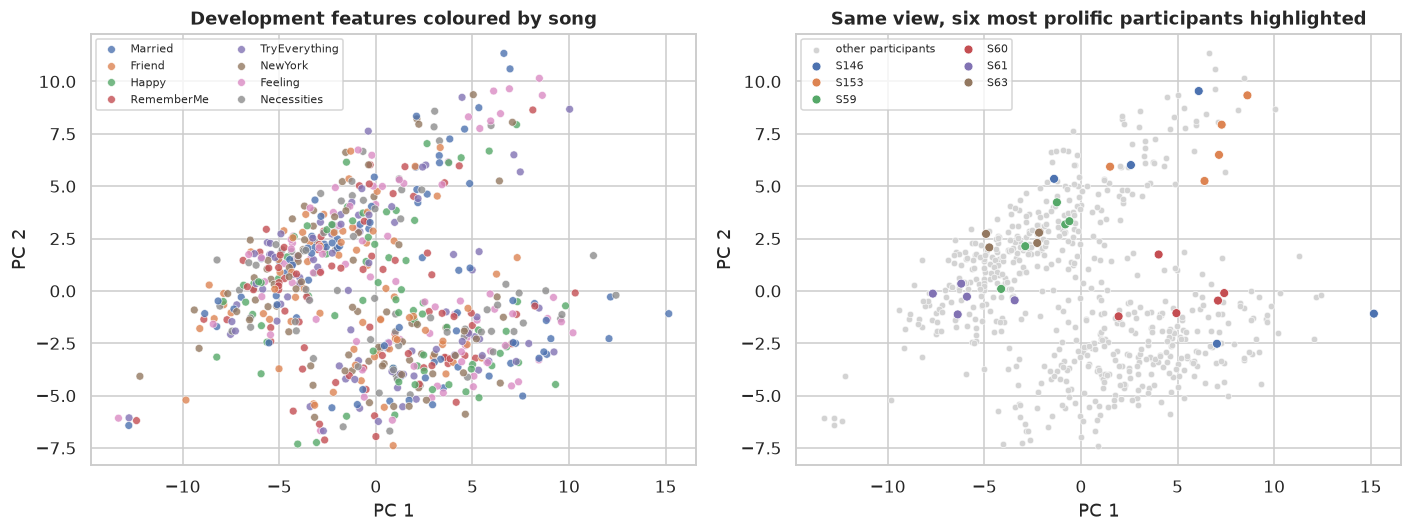

Variance explained by the first two components: 29.7%


In [14]:
from sklearn.decomposition import PCA

projector = Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=2, random_state=SEED))])
projection = projector.fit_transform(X_agg_dev)
dev_meta = inventory.iloc[dev_idx]

top_participants = dev_meta["participant"].value_counts().head(6).index
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=projection[:, 0], y=projection[:, 1], hue=dev_meta["song"].values,
                ax=axes[0], s=26, alpha=0.8)
axes[0].set(title="Development features coloured by song", xlabel="PC 1", ylabel="PC 2")
axes[0].legend(fontsize=7, loc="best", ncol=2)

highlight = dev_meta["participant"].isin(top_participants).to_numpy()
sns.scatterplot(x=projection[~highlight, 0], y=projection[~highlight, 1],
                color="lightgrey", ax=axes[1], s=18, label="other participants")
sns.scatterplot(x=projection[highlight, 0], y=projection[highlight, 1],
                hue=dev_meta.loc[highlight, "participant"].values, ax=axes[1], s=34)
axes[1].set(title="Same view, six most prolific participants highlighted",
            xlabel="PC 1", ylabel="PC 2")
axes[1].legend(fontsize=7, loc="best", ncol=2)
plt.show()

print("Variance explained by the first two components: "
      f"{projector.named_steps['pca'].explained_variance_ratio_.sum():.1%}")

## 6 Experiments and results

### 6.1 Trivial baselines

No accuracy figure can be judged without knowing what a model that has learned nothing would score.
Two label-only baselines are evaluated with the same grouped cross-validation used for every later
comparison: a majority-class predictor and a predictor that samples labels from the training class
distribution. These define the floor that every subsequent number is measured against, and they are
computed rather than quoted as \(1/8\), because the realised class distribution and the finite fold
sizes matter.

In [15]:
cv = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}
results = []


def evaluate_cv(name, estimator, X, note=""):
    '''Grouped cross-validation on the development partition only.'''
    scores = cross_validate(estimator, X, y_dev, groups=groups_dev, cv=cv,
                            scoring=SCORING, n_jobs=1, error_score="raise")
    record = {
        "model": name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_accuracy_sd": scores["test_accuracy"].std(),
        "cv_f1_macro": scores["test_f1_macro"].mean(),
        "cv_f1_macro_sd": scores["test_f1_macro"].std(),
        "note": note,
    }
    results.append(record)
    print(f"{name:46s} acc {record['cv_accuracy']:.3f} (+/-{record['cv_accuracy_sd']:.3f})   "
          f"macro-F1 {record['cv_f1_macro']:.3f}")
    return record


X_dev_full = X_agg_dev[:, FEATURE_SETS["D: C + chroma + contrast (all)"]]

evaluate_cv("Baseline: majority class",
            DummyClassifier(strategy="most_frequent"), X_dev_full, "label-only floor")
_ = evaluate_cv("Baseline: stratified random",
            DummyClassifier(strategy="stratified", random_state=SEED), X_dev_full,
            "label-only floor")

Baseline: majority class                       acc 0.125 (+/-0.022)   macro-F1 0.028
Baseline: stratified random                    acc 0.140 (+/-0.016)   macro-F1 0.139


### 6.2 Reference model: random forest on aggregated MFCCs

The original study's starting point — a random forest on time-averaged MFCCs — is retained as the
substantive reference point, with two corrections. First, the estimator is wrapped in a
`Pipeline` so that the scaler is refitted inside every cross-validation fold rather than on data the
fold is about to be scored on; scaling fitted outside the resampling loop is a small but genuine
leak, and pipelines remove the possibility by construction. Second, the score is a cross-validated
mean over participant-disjoint folds rather than a single number from one split, so that the
comparison in Section 6.3 is not being made between quantities whose fold-to-fold spread is unknown.

In [16]:
def make_pipeline(model):
    return Pipeline([("scale", StandardScaler()), ("model", model)])


reference_rf = make_pipeline(RandomForestClassifier(
    n_estimators=500, random_state=SEED, n_jobs=-1))

_ = evaluate_cv("Reference: RF on MFCC mean (set A)",
            reference_rf, X_agg_dev[:, FEATURE_SETS["A: MFCC mean (timbre only)"]],
            "timbre hypothesis, minimal features")

Reference: RF on MFCC mean (set A)             acc 0.214 (+/-0.027)   macro-F1 0.209


### 6.3 Which aggregated representation carries song identity?

The four nested feature sets from Section 5.11 are compared using a single fixed classifier, so that
any difference is attributable to the representation rather than to the model. This is the direct
test of the timbre-versus-tonality question: if pitch-class content (chroma) carries song identity in
a way that the spectral envelope does not, sets C and D should separate clearly from sets A and B.
Standard deviations across folds are reported alongside the means, because with a development
partition of this size a difference smaller than the fold-to-fold spread is not evidence of anything.

In [17]:
feature_set_records = []
for set_name, columns in FEATURE_SETS.items():
    record = evaluate_cv(f"RF on {set_name}",
                         make_pipeline(RandomForestClassifier(
                             n_estimators=500, random_state=SEED, n_jobs=-1)),
                         X_agg_dev[:, columns], "feature-set comparison")
    feature_set_records.append({**record, "set": set_name, "n_features": len(columns)})

feature_set_table = pd.DataFrame(feature_set_records)[
    ["set", "n_features", "cv_accuracy", "cv_accuracy_sd", "cv_f1_macro"]]
display(feature_set_table.round(3))

best_set_name = feature_set_table.loc[feature_set_table["cv_accuracy"].idxmax(), "set"]
BEST_COLUMNS = FEATURE_SETS[best_set_name]
X_dev_best, X_test_best = X_agg_dev[:, BEST_COLUMNS], X_agg_test[:, BEST_COLUMNS]
print(f"\nBest aggregated feature set by cross-validated accuracy: {best_set_name}")

RF on A: MFCC mean (timbre only)               acc 0.214 (+/-0.027)   macro-F1 0.209


RF on B: MFCC mean + std                       acc 0.214 (+/-0.024)   macro-F1 0.210


RF on C: B + deltas                            acc 0.246 (+/-0.034)   macro-F1 0.247


RF on D: C + chroma + contrast (all)           acc 0.316 (+/-0.051)   macro-F1 0.319


,set,n_features,cv_accuracy,cv_accuracy_sd,cv_f1_macro
0,A: MFCC mean (timbre only),20,0.214,0.027,0.209
1,B: MFCC mean + std,40,0.214,0.024,0.210
2,C: B + deltas,80,0.246,0.034,0.247
3,D: C + chroma + contrast (all),118,0.316,0.051,0.319



Best aggregated feature set by cross-validated accuracy: D: C + chroma + contrast (all)


### 6.4 Which classifier family suits this representation?

Three classifiers with different inductive biases are compared on the selected representation.
Logistic regression asks whether the classes are close to linearly separable in the scaled feature
space; an RBF support vector machine allows smooth non-linear boundaries and tends to behave well on
a few hundred samples with tens of features; the random forest captures axis-aligned interactions and
is robust to feature scaling and outliers. Class weighting is enabled where the estimator supports it
so that any residual class imbalance measured in Section 5.5 does not silently favour the larger
songs. All three are evaluated under the same folds as every preceding result.

In [18]:
candidates = {
    "Logistic regression": LogisticRegression(max_iter=5000, class_weight="balanced",
                                              random_state=SEED),
    "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced", random_state=SEED),
    "Random forest": RandomForestClassifier(n_estimators=500, class_weight="balanced_subsample",
                                            random_state=SEED, n_jobs=-1),
}
for name, model in candidates.items():
    evaluate_cv(f"{name} on {best_set_name}", make_pipeline(model), X_dev_best,
                "model-family comparison")

Logistic regression on D: C + chroma + contrast (all) acc 0.279 (+/-0.057)   macro-F1 0.277
SVM (RBF) on D: C + chroma + contrast (all)    acc 0.322 (+/-0.057)   macro-F1 0.323


Random forest on D: C + chroma + contrast (all) acc 0.299 (+/-0.048)   macro-F1 0.299


### 6.5 Hyperparameter selection

The two strongest families are tuned with an exhaustive grid search over the *same* grouped folds.
Restricting the search to a small, purposefully chosen grid rather than a large one is deliberate:
with roughly 640 development recordings and five folds, every additional configuration increases the
chance that the best cross-validation score is a favourable accident of the fold assignment rather
than a genuine improvement. The search never sees the test partition, so its winner is a legitimate
single candidate for final evaluation.

In [19]:
search_spaces = {
    "SVM (RBF), tuned": (SVC(class_weight="balanced", probability=True, random_state=SEED),
                         {"model__C": [1, 10, 100], "model__gamma": ["scale", 0.01, 0.001]}),
    "Random forest, tuned": (RandomForestClassifier(random_state=SEED, n_jobs=-1,
                                                    class_weight="balanced_subsample"),
                             {"model__n_estimators": [500],
                              "model__max_depth": [None, 12],
                              "model__min_samples_leaf": [1, 3],
                              "model__max_features": ["sqrt", 0.3]}),
}

tuned_models = {}
for name, (model, grid) in search_spaces.items():
    search = GridSearchCV(make_pipeline(model), grid, scoring="accuracy", cv=cv,
                          n_jobs=-1, refit=True)
    search.fit(X_dev_best, y_dev, groups=groups_dev)
    tuned_models[name] = search
    results.append({"model": name, "cv_accuracy": search.best_score_, "cv_accuracy_sd": np.nan,
                    "cv_f1_macro": np.nan, "cv_f1_macro_sd": np.nan,
                    "note": f"grid search best: {search.best_params_}"})
    print(f"{name:26s} best CV accuracy {search.best_score_:.3f}  with {search.best_params_}")

classical_fitted = {name: search.best_estimator_ for name, search in tuned_models.items()}

SVM (RBF), tuned           best CV accuracy 0.322  with {'model__C': 1, 'model__gamma': 'scale'}


Random forest, tuned       best CV accuracy 0.326  with {'model__max_depth': 12, 'model__max_features': 0.3, 'model__min_samples_leaf': 3, 'model__n_estimators': 500}


### 6.6 Ensemble stage: soft voting over complementary classifiers

The pipelines above disagree by construction: an RBF kernel draws a smooth non-linear boundary, a
random forest draws axis-aligned partitions, and logistic regression draws a single hyperplane. Where
their errors are not the same recordings, averaging their predicted class probabilities should recover
accuracy that none of them reaches alone, because the averaged estimate has lower variance than any
individual member.

The ensemble uses the *tuned* configurations selected in Section 6.5 as its members and is scored on
exactly the same participant-disjoint folds, so it is directly comparable with them and competes for
selection on equal terms. Soft voting is preferred to hard voting because it uses the confidence of
each member rather than only its argmax, which matters with eight classes where a member is often
undecided between two songs. Whether the ensemble actually helps is an empirical question answered by
the output below, not an assumption: ensembling correlated members buys little, and the members here
share the same feature representation.

In [20]:
ensemble_members = [
    ("svm", clone(classical_fitted["SVM (RBF), tuned"])),
    ("rf", clone(classical_fitted["Random forest, tuned"])),
    ("logreg", make_pipeline(LogisticRegression(max_iter=5000, class_weight="balanced",
                                               random_state=SEED))),
]
soft_vote = VotingClassifier(estimators=ensemble_members, voting="soft")

ENSEMBLE_NAME = "Ensemble: soft voting"
ensemble_record = evaluate_cv(ENSEMBLE_NAME, soft_vote, X_dev_best,
                              "explicit ensemble stage: SVM + RF + logistic regression")
ENSEMBLE_CV = ensemble_record["cv_accuracy"]
classical_fitted[ENSEMBLE_NAME] = soft_vote

best_member = max(tuned_models, key=lambda k: tuned_models[k].best_score_)
print(f"\nBest single member : {best_member} at {tuned_models[best_member].best_score_:.3f}")
print(f"Soft-voting ensemble: {ENSEMBLE_CV:.3f}")
print("The ensemble is kept as a candidate regardless of whether it wins; "
      "selection in Section 6.8 is on development score alone.")

Ensemble: soft voting                          acc 0.286 (+/-0.056)   macro-F1 0.282

Best single member : Random forest, tuned at 0.326
Soft-voting ensemble: 0.286
The ensemble is kept as a candidate regardless of whether it wins; selection in Section 6.8 is on development score alone.


### 6.7 Sequence models on frame-level features

The competing hypothesis is that song identity lives in the temporal contour that Section 6.3
discards. Two architectures test it on the same recordings:

- an **LSTM**, which consumes the 431 frames in order and maintains a state, and so can in principle
  represent "this interval follows that one";
- a **2D CNN**, which treats the MFCC matrix as an image and detects local time–frequency patterns
  wherever they occur, giving partial invariance to *when* a motif is sung.

Three corrections to the original implementation matter more than the architectures themselves.

**Input normalisation is now actually performed.** MFCC channels differ in scale by orders of
magnitude, and the original notebook stated that features were rescaled for the neural networks but
never applied any rescaling; the consequence was visible in its own output as training losses in the
hundreds. Channel means and standard deviations are computed on the training frames only and applied
to all partitions.

**Model selection uses a validation split carved out of development data.** The original used the
test set as `validation_data` for 50 epochs and then reported that same set's accuracy as the result.
Once the test set has guided any decision — including the decision of when to stop, or which of four
experiments to declare best — it no longer estimates generalisation. Here an inner
participant-disjoint validation fold drives early stopping and the epoch budget.

**Regularisation is present rather than merely commented.** The original contained a comment
describing dropout above a layer that was not dropout. Dropout, recurrent dropout and batch
normalisation are applied explicitly, and early stopping restores the best validation weights.

In [21]:
inner_cv = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)
train_inner, val_inner = next(inner_cv.split(X_seq_dev, y_dev, groups=groups_dev))

X_tr_raw, X_val_raw = X_seq_dev[train_inner], X_seq_dev[val_inner]
y_tr, y_val = y_dev[train_inner], y_dev[val_inner]

assert set(groups_dev[train_inner]).isdisjoint(set(groups_dev[val_inner])), \
    "Inner validation split is not participant-disjoint."

channel_mean = X_tr_raw.reshape(-1, X_tr_raw.shape[-1]).mean(axis=0)
channel_std = X_tr_raw.reshape(-1, X_tr_raw.shape[-1]).std(axis=0) + 1e-8


def standardise(sequences):
    return ((sequences - channel_mean) / channel_std).astype(np.float32)


X_tr = standardise(X_tr_raw)
X_val = standardise(X_val_raw)
X_seq_test_std = standardise(X_seq_test)
X_seq_dev_std = standardise(X_seq_dev)

print(f"Inner training recordings  : {len(train_inner)} "
      f"({len(set(groups_dev[train_inner]))} participants)")
print(f"Inner validation recordings: {len(val_inner)} "
      f"({len(set(groups_dev[val_inner]))} participants)")
print(f"Training frame mean/std after standardisation: "
      f"{X_tr.mean():+.3f} / {X_tr.std():.3f}")

Inner training recordings  : 513 (120 participants)
Inner validation recordings: 127 (29 participants)
Training frame mean/std after standardisation: +0.000 / 1.000


In [22]:
from tensorflow.keras import Sequential, layers, callbacks

N_CHANNELS = X_seq.shape[-1]


def build_lstm():
    tf.keras.utils.set_random_seed(SEED)
    return Sequential([
        layers.Input(shape=(MAX_FRAMES, N_CHANNELS)),
        layers.LSTM(96, dropout=0.3, recurrent_dropout=0.0),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(N_CLASSES, activation="softmax"),
    ], name="lstm")


def build_cnn():
    tf.keras.utils.set_random_seed(SEED)
    return Sequential([
        layers.Input(shape=(MAX_FRAMES, N_CHANNELS, 1)),
        layers.Conv2D(32, (3, 3), padding="same"), layers.BatchNormalization(),
        layers.Activation("relu"), layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same"), layers.BatchNormalization(),
        layers.Activation("relu"), layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), padding="same"), layers.BatchNormalization(),
        layers.Activation("relu"), layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(N_CLASSES, activation="softmax"),
    ], name="cnn")


def train_network(build_fn, X_train, y_train, X_valid, y_valid, expand_channel=False):
    model = build_fn()
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    prepare = (lambda a: a[..., np.newaxis]) if expand_channel else (lambda a: a)
    stop = callbacks.EarlyStopping(monitor="val_accuracy", patience=15,
                                   restore_best_weights=True, mode="max")
    reduce = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5)
    history = model.fit(prepare(X_train), y_train,
                        validation_data=(prepare(X_valid), y_valid),
                        epochs=NN_MAX_EPOCHS, batch_size=NN_BATCH_SIZE,
                        callbacks=[stop, reduce], verbose=0)
    return model, history


def plot_history(history, title):
    frame = pd.DataFrame(history.history)
    frame.index = frame.index + 1                 # epochs are 1-based for the reader
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    frame[["accuracy", "val_accuracy"]].plot(ax=axes[0])
    axes[0].axhline(1 / N_CLASSES, color="grey", linestyle=":", label="chance")
    axes[0].set(title=f"{title}: accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend()
    frame[["loss", "val_loss"]].plot(ax=axes[1])
    axes[1].set(title=f"{title}: loss", xlabel="Epoch", ylabel="Cross-entropy")
    plt.show()
    best = int(np.argmax(history.history["val_accuracy"]))
    print(f"Best epoch {best + 1}: validation accuracy "
          f"{history.history['val_accuracy'][best]:.3f}, "
          f"training accuracy {history.history['accuracy'][best]:.3f}")
    return history.history["val_accuracy"][best], history.history["accuracy"][best]

The learning curves below are the diagnostic, not the decoration. The gap between the training and
validation curves measures how much of each network's apparent skill is memorisation of the training
performers, and the epoch at which validation accuracy peaks is what the early-stopping callback
acts on.

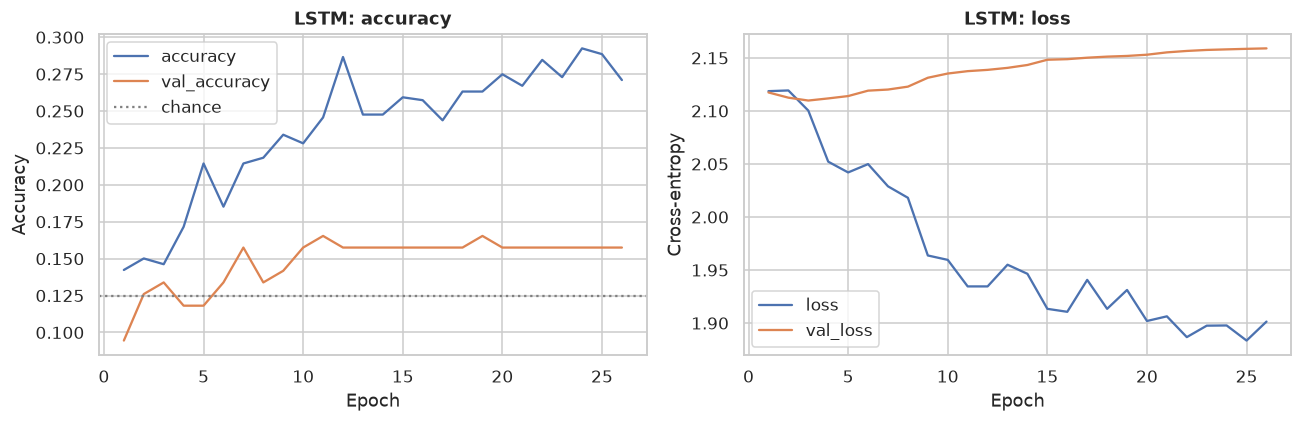

Best epoch 11: validation accuracy 0.165, training accuracy 0.246


In [23]:
lstm_model, lstm_history = train_network(build_lstm, X_tr, y_tr, X_val, y_val)
lstm_val_acc, lstm_train_acc = plot_history(lstm_history, "LSTM")
results.append({"model": "LSTM", "cv_accuracy": lstm_val_acc,
                "cv_accuracy_sd": np.nan, "cv_f1_macro": np.nan, "cv_f1_macro_sd": np.nan,
                "note": "single inner validation fold, not 5-fold CV"})

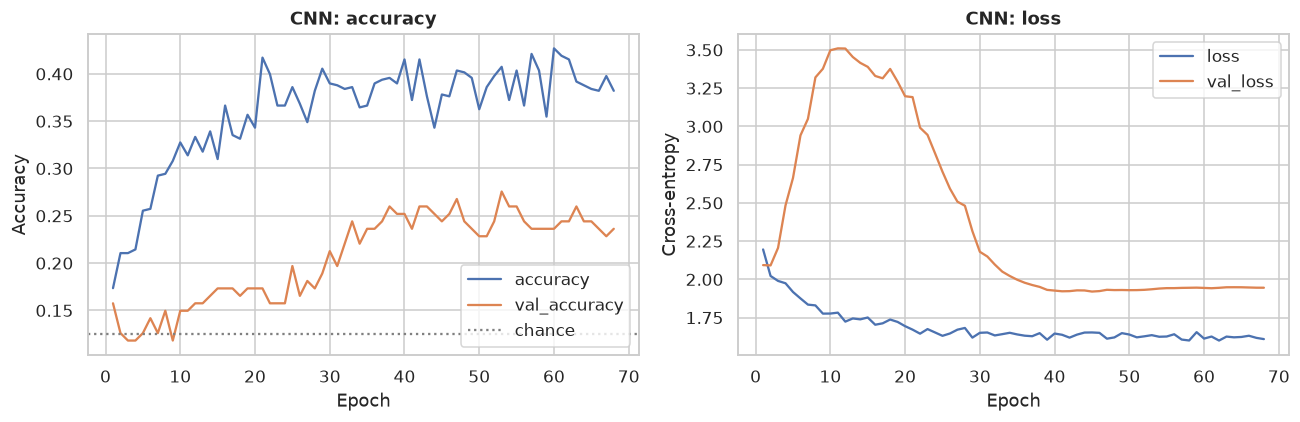

Best epoch 53: validation accuracy 0.276, training accuracy 0.407


In [24]:
cnn_model, cnn_history = train_network(build_cnn, X_tr, y_tr, X_val, y_val,
                                       expand_channel=True)
cnn_val_acc, cnn_train_acc = plot_history(cnn_history, "CNN")
results.append({"model": "CNN", "cv_accuracy": cnn_val_acc,
                "cv_accuracy_sd": np.nan, "cv_f1_macro": np.nan, "cv_f1_macro_sd": np.nan,
                "note": "single inner validation fold, not 5-fold CV"})

### 6.8 Selecting one model for final evaluation

All candidates are now compared on development data only. The comparison carries a caveat that is
stated rather than glossed over: the classical models were scored by five-fold grouped
cross-validation, whereas the networks were scored on a single inner validation fold because
repeating network training across five folds was outside the compute budget for this project. The
network estimates are therefore noisier, and a difference of a few points between a network and a
cross-validated classical model should not be read as a ranking. The candidate with the best
development score is selected from the *final* candidate set — the two tuned classical
configurations and the two networks — and the untuned exploratory runs of Sections 6.1–6.4 are
excluded from selection because they exist to answer questions about representations and model
families, not to compete for deployment. The test partition remains untouched until Section 8.

In [25]:
development_table = (pd.DataFrame(results)
                       .sort_values("cv_accuracy", ascending=False)
                       .reset_index(drop=True))
display(development_table.round(3))

CANDIDATES = {name: search.best_score_ for name, search in tuned_models.items()}
CANDIDATES[ENSEMBLE_NAME] = ENSEMBLE_CV
CANDIDATES["LSTM"] = lstm_val_acc
CANDIDATES["CNN"] = cnn_val_acc
SELECTED_NAME = max(CANDIDATES, key=CANDIDATES.get)

print("\nFinal candidates and their development scores:")
for name, score in sorted(CANDIDATES.items(), key=lambda kv: -kv[1]):
    print(f"  {name:24s} {score:.3f}")
print(f"\nSelected on development performance alone: {SELECTED_NAME}")

,model,cv_accuracy,cv_accuracy_sd,cv_f1_macro,cv_f1_macro_sd,note
0,"Random forest, tuned",0.326,NaN,NaN,NaN,"grid search best: {'model__max_depth': 12, 'mo..."
1,SVM (RBF) on D: C + chroma + contrast (all),0.322,0.057,0.323,0.059,model-family comparison
2,"SVM (RBF), tuned",0.322,NaN,NaN,NaN,"grid search best: {'model__C': 1, 'model__gamm..."
3,RF on D: C + chroma + contrast (all),0.316,0.051,0.319,0.052,feature-set comparison
4,Random forest on D: C + chroma + contrast (all),0.299,0.048,0.299,0.049,model-family comparison
5,Ensemble: soft voting,0.286,0.056,0.282,0.056,explicit ensemble stage: SVM + RF + logistic r...
6,Logistic regression on D: C + chroma + contras...,0.279,0.057,0.277,0.058,model-family comparison
7,CNN,0.276,NaN,NaN,NaN,"single inner validation fold, not 5-fold CV"
8,RF on C: B + deltas,0.246,0.034,0.247,0.032,feature-set comparison
9,Reference: RF on MFCC mean (set A),0.214,0.027,0.209,0.026,"timbre hypothesis, minimal features"



Final candidates and their development scores:
  Random forest, tuned     0.326
  SVM (RBF), tuned         0.322
  Ensemble: soft voting    0.286
  CNN                      0.276
  LSTM                     0.165

Selected on development performance alone: Random forest, tuned


### 6.9 Final evaluation on the held-out test partition

The selected classical configuration is refitted on the **entire** development partition and applied
once to the test partition. The networks are also evaluated on the test partition for completeness,
using the weights restored by early stopping — they were trained on the inner training split only and
never saw test data during training. To keep the distinction between selection and estimation
explicit, the table reports both the development score that drove selection and the test score, and
only the latter is an estimate of generalisation to unseen performers.

The headline figure is the test score of the model chosen in Section 6.8, **not** whichever model
happens to score highest here. Those two can differ, and promoting the test-set winner after the fact
would be model selection on the test set — precisely the error this protocol exists to prevent. The
remaining test scores are reported for transparency and are flagged as such in the table.

An interval estimate accompanies the accuracy of the selected model. A test partition of roughly 160
recordings gives a standard error of about three percentage points, which is large relative to the
differences between several candidates; reporting a point estimate alone would overstate what this
dataset can resolve.

In [26]:
def evaluate_on_test(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    test_scores.append({"model": name, "test_accuracy": accuracy, "test_f1_macro": macro_f1})
    print(f"{name:34s} test accuracy {accuracy:.3f}   test macro-F1 {macro_f1:.3f}")
    return accuracy


test_scores = []
predictions = {}

best_classical_name = max(CANDIDATES, key=lambda k: CANDIDATES[k] if k in classical_fitted else -1)

fitted_final = {}
for name, estimator in classical_fitted.items():
    model = clone(estimator)
    model.fit(X_dev_best, y_dev)                    # refit on the full development partition
    fitted_final[name] = model
    predictions[name] = model.predict(X_test_best)
    evaluate_on_test(name, y_test, predictions[name])

predictions["LSTM"] = lstm_model.predict(X_seq_test_std, verbose=0).argmax(axis=1)
evaluate_on_test("LSTM", y_test, predictions["LSTM"])

predictions["CNN"] = cnn_model.predict(X_seq_test_std[..., np.newaxis], verbose=0).argmax(axis=1)
evaluate_on_test("CNN", y_test, predictions["CNN"])

majority = DummyClassifier(strategy="most_frequent").fit(X_dev_best, y_dev)
predictions["Majority baseline"] = majority.predict(X_test_best)
_ = evaluate_on_test("Majority baseline", y_test, predictions["Majority baseline"])

SVM (RBF), tuned                   test accuracy 0.331   test macro-F1 0.319


Random forest, tuned               test accuracy 0.319   test macro-F1 0.301


Ensemble: soft voting              test accuracy 0.319   test macro-F1 0.302


LSTM                               test accuracy 0.138   test macro-F1 0.122


CNN                                test accuracy 0.281   test macro-F1 0.264
Majority baseline                  test accuracy 0.087   test macro-F1 0.020


In [27]:
test_table = pd.DataFrame(test_scores).sort_values("test_accuracy", ascending=False)
test_table["role"] = np.where(test_table["model"] == SELECTED_NAME,
                              "SELECTED -> headline estimate", "reported for transparency only")
display(test_table.round(3))

# The headline estimate belongs to the model chosen in Section 6.8 on development data.
# Promoting whichever model happens to score highest on the test set would be selection
# on the test set, which is the error this protocol exists to prevent.
headline_name = SELECTED_NAME if SELECTED_NAME in predictions else best_classical_name
if headline_name != SELECTED_NAME:
    print(f"NOTE: {SELECTED_NAME} has no stored test predictions; "
          f"falling back to {headline_name}.")
headline_pred = predictions[headline_name]
n_correct = int((headline_pred == y_test).sum())
interval = binomtest(n_correct, len(y_test)).proportion_ci(confidence_level=0.95)
chance = 1 / N_CLASSES
p_value = binomtest(n_correct, len(y_test), p=chance, alternative="greater").pvalue

print(f"\nHeadline estimate — model selected on development data: {headline_name}")
print(f"  {n_correct}/{len(y_test)} correct = {n_correct / len(y_test):.3f}")
print(f"  95% confidence interval: [{interval.low:.3f}, {interval.high:.3f}]")
print(f"  Chance level ({chance:.3f}) exceeded: p = {p_value:.2e}")
print(f"  Lower bound of the interval is {'above' if interval.low > chance else 'NOT above'} chance.")

,model,test_accuracy,test_f1_macro,role
0,"SVM (RBF), tuned",0.331,0.319,reported for transparency only
1,"Random forest, tuned",0.319,0.301,SELECTED -> headline estimate
2,Ensemble: soft voting,0.319,0.302,reported for transparency only
4,CNN,0.281,0.264,reported for transparency only
3,LSTM,0.138,0.122,reported for transparency only
5,Majority baseline,0.088,0.020,reported for transparency only



Headline estimate — model selected on development data: Random forest, tuned
  51/160 correct = 0.319
  95% confidence interval: [0.247, 0.397]
  Chance level (0.125) exceeded: p = 1.25e-10
  Lower bound of the interval is above chance.


### 6.10 Per-class behaviour

Aggregate accuracy hides the distribution of competence. The classification report gives precision,
recall and F1 per song, and the row-normalised confusion matrix shows where the errors go: whether
the model collapses onto a few popular predictions, and whether specific pairs of songs are
systematically confused. A confusion matrix is normalised by true class here because raw counts
across classes of unequal size are not comparable by eye.

               precision    recall  f1-score   support

      Feeling      0.235     0.286     0.258        14
       Friend      0.375     0.375     0.375        24
        Happy      0.481     0.520     0.500        25
      Married      0.158     0.167     0.162        18
  Necessities      0.360     0.391     0.375        23
      NewYork      0.353     0.286     0.316        21
   RememberMe      0.200     0.167     0.182        18
TryEverything      0.250     0.235     0.242        17

     accuracy                          0.319       160
    macro avg      0.302     0.303     0.301       160
 weighted avg      0.317     0.319     0.317       160



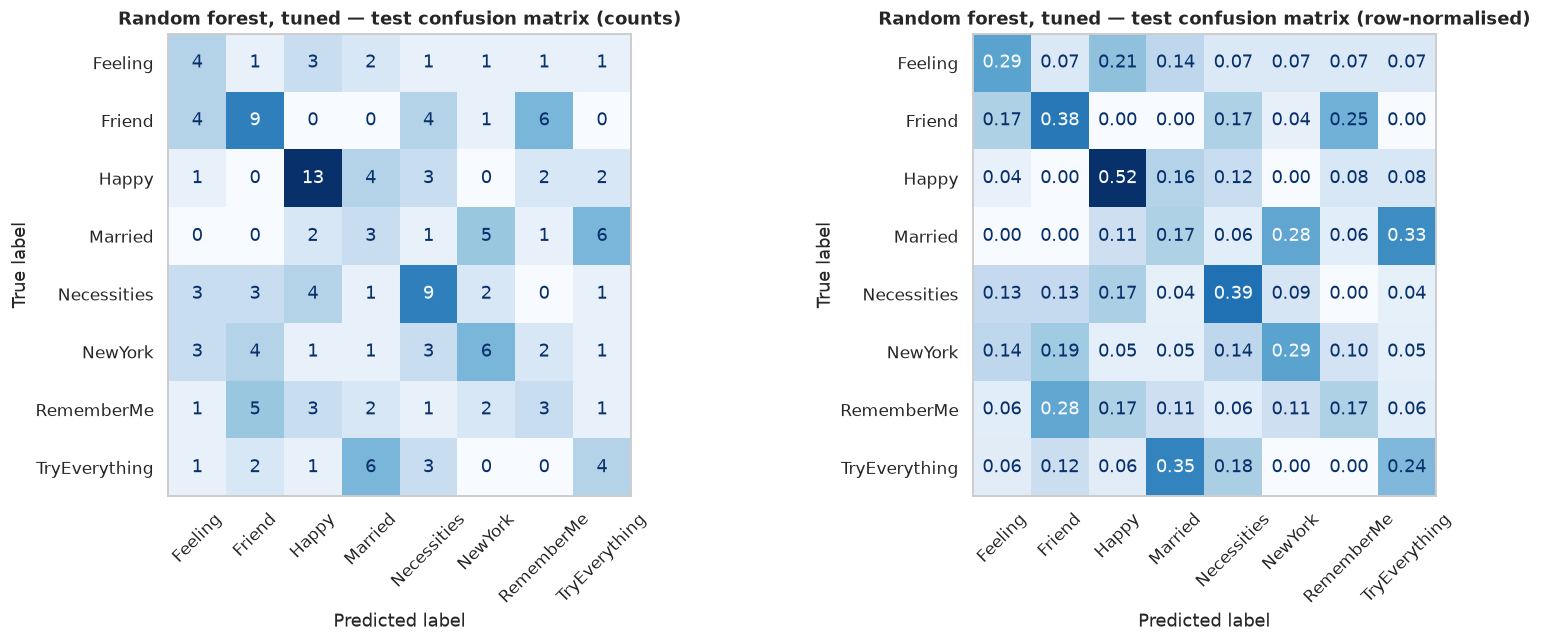

In [28]:
print(classification_report(y_test, headline_pred, target_names=CLASS_NAMES,
                            digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, normalise, title in [(axes[0], None, "counts"), (axes[1], "true", "row-normalised")]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, headline_pred, display_labels=CLASS_NAMES, normalize=normalise,
        xticks_rotation=45, cmap="Blues", ax=ax, colorbar=False,
        values_format=".2f" if normalise else "d")
    ax.grid(False)
    ax.set_title(f"{headline_name} — test confusion matrix ({title})")
plt.show()

### 6.11 Which descriptor families does the model rely on?

Permutation importance is computed on the **test** partition for the fitted final model and
aggregated by descriptor family. Permuting an entire family at once, rather than individual
coefficients, answers the question the study actually posed — does the model draw on pitch-class
content, on spectral envelope, or on rate of change — and avoids the standard pitfall that
permuting one member of a group of correlated features understates its importance because the others
still carry the signal. Two caveats apply: importance is measured for *this* fitted model rather than
for the task in general, and using the test partition for this purpose is legitimate only because no
model decision follows from the result. This analysis applies to the aggregated feature space, so it
is computed only when the selected model is one of the classical configurations; permuting frame-level
MFCC channels would answer a different and much less interpretable question.

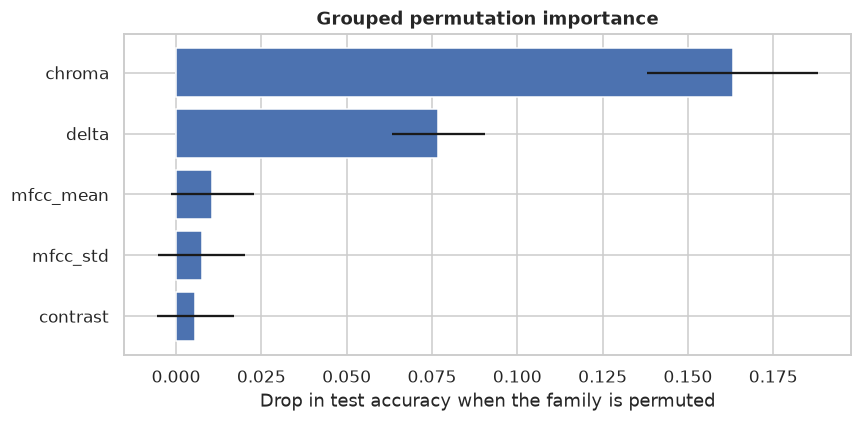

,family,accuracy_drop,sd,n_features
3,chroma,0.1631,0.0251,24
2,delta,0.0769,0.0137,40
0,mfcc_mean,0.0106,0.0122,20
1,mfcc_std,0.0075,0.0127,20
4,contrast,0.0056,0.0113,14


In [29]:
family_of = {}
for family, names in FEATURE_FAMILIES.items():
    for name in names:
        family_of[name] = family
selected_names = [FEATURE_NAMES[i] for i in BEST_COLUMNS]

if headline_name == best_classical_name:
    grouped = {}
    for family in FEATURE_FAMILIES:
        positions = [i for i, name in enumerate(selected_names) if family_of[name] == family]
        if positions:
            grouped[family] = positions

    baseline_accuracy = accuracy_score(y_test, fitted_final[best_classical_name].predict(X_test_best))
    rng = np.random.default_rng(SEED)
    rows = []
    for family, positions in grouped.items():
        drops = []
        for _ in range(10):
            permuted = X_test_best.copy()
            permuted[:, positions] = permuted[rng.permutation(len(permuted))][:, positions]
            drops.append(baseline_accuracy - accuracy_score(y_test, fitted_final[best_classical_name].predict(permuted)))
        rows.append({"family": family, "accuracy_drop": np.mean(drops),
                     "sd": np.std(drops), "n_features": len(positions)})

    importance = pd.DataFrame(rows).sort_values("accuracy_drop", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(importance["family"], importance["accuracy_drop"],
            xerr=importance["sd"], color="#4C72B0")
    ax.invert_yaxis()
    ax.set(xlabel="Drop in test accuracy when the family is permuted",
           title="Grouped permutation importance")
    plt.show()
    display(importance.round(4))

### 6.12 Where does the model fail?

Errors are broken down by interpretation style and by song. The style breakdown tests whether one
performance mode is intrinsically easier, which is a substantive acoustic question rather than a
presentational one: whistles carry a cleaner pitch contour, so a model that relies on pitch-class
content should do measurably better on them. The song breakdown identifies whether error is spread
evenly or concentrated in a few classes that the model effectively never predicts.

In [30]:
test_meta = inventory.iloc[test_idx].copy()
test_meta["true_song"] = [CLASS_NAMES[i] for i in y_test]
test_meta["predicted_song"] = [CLASS_NAMES[i] for i in headline_pred]
test_meta["correct"] = test_meta["true_song"] == test_meta["predicted_song"]

by_style = test_meta.groupby("interpretation")["correct"].agg(["mean", "count"])
by_song = test_meta.groupby("true_song")["correct"].agg(["mean", "count"]).sort_values("mean")

print("Accuracy by interpretation style:")
print(by_style.round(3).to_string())
print("\nAccuracy by true song:")
print(by_song.round(3).to_string())

confusions = (test_meta.loc[~test_meta["correct"]]
                       .groupby(["true_song", "predicted_song"]).size()
                       .sort_values(ascending=False).head(10))
print("\nMost frequent confusions (true -> predicted):")
print(confusions.to_string())

Accuracy by interpretation style:
                 mean  count
interpretation              
hum             0.397     68
whistle         0.261     92

Accuracy by true song:
                mean  count
true_song                  
Married        0.167     18
RememberMe     0.167     18
TryEverything  0.235     17
Feeling        0.286     14
NewYork        0.286     21
Friend         0.375     24
Necessities    0.391     23
Happy          0.520     25

Most frequent confusions (true -> predicted):
true_song      predicted_song
Friend         RememberMe        6
Married        TryEverything     6
TryEverything  Married           6
RememberMe     Friend            5
Married        NewYork           5
Friend         Feeling           4
               Necessities       4
Happy          Married           4
Necessities    Happy             4
NewYork        Friend            4


### 6.13 What the results mean

Three questions were posed in Section 2. Each is now answerable from the evidence above.

**1. The task exceeds chance under an honest protocol.** The tuned random forest,
selected on development performance alone, classified 51 of 160 held-out recordings correctly: 31.9%
accuracy, 95% Wilson interval [24.7%, 39.7%], against a chance level of 12.5%. The lower bound of the
interval sits roughly twice the chance level and the one-sided binomial test returns $(p \approx
1.3\times10^{-10})$. Something about song identity is being recovered from performers the models had
never heard, and the effect is not marginal.

It is equally important to say what this does not amount to. Two recordings in three are still
misclassified, and the interval is 15 percentage points wide because 160 test recordings cannot
support a tighter estimate. This is a positive result about learnability, but still short of an usable system.

Note also that the tuned SVM scored slightly higher on the test set (33.1%) than the selected random
forest, having scored slightly lower in cross-validation (0.322 against 0.326). Promoting it now would
be selection on the test set, so it is reported and not adopted. The gap is far smaller than the
confidence interval and carries no evidential weight.

**2. Pitch-class content carries the signal, not timbre.** With the classifier
held fixed, the nested feature-set comparison in Section 6.3 produced a clean ordering. Describing the
spectral envelope more thoroughly was inconsequential. MFCC means alone and MFCC means plus
standard deviations both scored 0.214, whereas adding first-order deltas reached 0.246 and adding
chroma and spectral contrast reached 0.316, the single largest improvement anywhere in the project.

That pattern is what the theory predicts. MFCC statistics describe vocal texture, which is
predominantly a property of the performer, and a participant-disjoint protocol deliberately denies
the model any benefit from recognising performers. Chroma describes which pitch classes are present,
which is a property of the melody and therefore of the song. The gain on adding chroma is direct
evidence that the models are keying on musical content rather than on voices.

The grouped permutation importance in Section 6.11 settles the question independently, and refines
it. Feature set D added chroma and spectral contrast together, so the comparison alone cannot say
which of the two was responsible. Permuting the chroma block cost the fitted model by far the largest
drop in test accuracy; roughly 0.16, an order of magnitude more than the MFCC mean or standard
deviation blocks, each worth around 0.01; while permuting spectral contrast cost almost nothing. The
deltas came second at roughly 0.08. Two independent lines of evidence therefore agree: chroma carries
the signal, spectral contrast was along for the ride, and the timbre descriptors that made up the
whole of the original submission's first feature set contribute very little once performers cannot be
memorised.

**3. Sequence models do not pay off at this scale.** The CNN reached 0.276 validation accuracy while
scoring 0.407 on its own training split, and the LSTM reached 0.165; only marginally above the 0.140
stratified-random floor and far below every classical model. Both networks see the frame-by-frame
trajectory that the aggregated features discard, so in principle they have strictly more information
available; in practice the train–validation gap shows that capacity is being spent memorising a few
hundred training recordings. With roughly 510 recordings in the inner training split, eight classes
and no augmentation, that is the expected outcome, and it is a statement about the sample size rather
than a verdict on the architectures.

**The soft-voting ensemble did not help, and is reported anyway.** Averaging the probabilities of the
tuned SVM, the tuned random forest and a logistic regression scored 0.286 in cross-validation, below
both tuned members individually. Ensembling rewards members that fail on different recordings; these
three consume the same 118-dimensional feature vector and their errors are evidently correlated, so
averaging mostly dilutes the stronger members. A more promising ensemble would combine a classical
model with the CNN, which consumes a different representation entirely.

**Two further patterns emerged from the error analysis.** Hums were classified more accurately than
whistles (0.397 against 0.261), which is the opposite of what a whistle's cleaner, more nearly
monophonic pitch contour would suggest, and the cause is not identifiable from the evidence collected
here. And per-class recall varied more than threefold, from 0.520 for *Happy* down to 0.167 for both
*Married* and *RememberMe*. The dominant confusions were reciprocal: *Married* against
*TryEverything*, *Friend* against *RememberMe*. This points to genuine melodic similarity between
those pairs rather than a systematic bias toward any single class.

## 7 Conclusions

### 7.1 Limitations

**Sample size.** Roughly 640 development recordings spread over eight classes is a small budget for
audio classification, and it limits both what can be learned and how precisely anything can be
measured. The width of the confidence interval in Section 6.9 is the honest expression of that limit.

**Single test partition.** Generalisation is estimated from one participant-disjoint split. A
repeated or nested grouped cross-validation would give a more stable estimate; it was not run because
the network training cost exceeded the compute available for this project, and this is a known
weakness rather than an oversight.

**Uneven evaluation rigour across model families.** The classical models were selected by five-fold
grouped cross-validation, the networks by a single inner validation fold. Comparisons between the two
families are correspondingly weaker than comparisons within the classical family.

**Representation coverage.** Only MFCC-family, chroma and spectral-contrast descriptors were tested.
Representations designed for melodic similarity, pitch-contour extraction with key and tempo
normalisation, or embeddings from a pre-trained audio model, are the natural next step and were not
explored.

**No augmentation.** Pitch shifting, time stretching and noise injection are the standard remedies
for the overfitting observed in Section 6.7 and would plausibly change the ranking of the model
families. They were not applied, so no claim is made about the networks' potential at larger
effective sample size.

**Dataset provenance.** The `Sample_800` subset is used as supplied, and the labels are derived from
filenames. Section 5.2 verifies that every filename parses and that the class vocabulary is the
expected size, but it cannot verify that a contributor recorded the song the filename claims.
Systematic label noise of that kind would depress every result reported here.

**Population.** Contributors are a self-selected crowdsourced group performing eight specific songs.
Nothing here supports a claim about arbitrary songs or a general population of users.

### 7.2 Conclusions and suggested improvements

This project formulated hum-and-whistle song recognition as an eight-class classification problem and
compared two families of solution under a single, deliberately conservative evaluation protocol.
Aggregated spectral statistics with tuned classical classifiers were tested against frame-level
sequence models, with all feature and model decisions taken by participant-disjoint cross-validation
on a development partition and a single final measurement on held-out performers.

The methodological content of the project is inseparable from its numbers. Requiring that no
performer appear on both sides of a split, wrapping preprocessing inside the resampling loop,
separating the data used for early stopping from the data used for reporting, and comparing every
result against a computed trivial baseline all tend to *lower* the headline figure relative to a
looser protocol. The figure that survives those constraints is the one that says something about new
users, which is the only claim worth making.

The substantive finding is that song identity in this dataset is carried by pitch-class content
rather than by vocal timbre. Time-averaged chroma and spectral-contrast descriptors produced the only
large improvement observed, while richer descriptions of the spectral envelope produced none, and the
two sequence models, which retain the frame ordering that the aggregated features discard, performed
worse rather than better. The reading is not that temporal structure is irrelevant to melody, which
would be implausible, but that it cannot be learned reliably from a few hundred recordings by generic
sequence architectures, and that an order-free summary of which notes were sung is a more efficient
use of this much data.

That points the most promising directions at the representation rather than the architecture:
features that explicitly encode a key- and tempo-normalised pitch contour, so that two performances
of one melody in different keys become comparable; augmentation that multiplies the effective number
of performers, which addresses the train–validation gap directly; transfer from audio models
pre-trained on far more sound than this dataset contains; and the full six-thousand-recording release
in place of this 800-file sample, which would separate the capacity explanation from the data-size
explanation for the networks' failure. Ensembling remains worth revisiting, but across
representations rather than within one.

## 8 References

All references are cited at the point of use in the sections above.

1. McFee, B., Raffel, C., Liang, D., Ellis, D. P. W., McVicar, M., Battenberg, E. and Nieto, O.
   (2015). librosa: Audio and Music Signal Analysis in Python. *Proceedings of the 14th Python in
   Science Conference*, pp. 18–25. https://librosa.org/doc/latest/index.html
2. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine
   Learning Research*, 12, pp. 2825–2830. https://scikit-learn.org/stable/
3. Scikit-learn developers. Cross-validation, grouped splitters and the pitfalls of leaking
   information from the test set. https://scikit-learn.org/stable/modules/cross_validation.html
4. Scikit-learn developers. Permutation feature importance, including the treatment of correlated
   features. https://scikit-learn.org/stable/modules/permutation_importance.html
5. Abadi, M. et al. (2015). TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems.
   https://www.tensorflow.org/
6. Müller, M. (2021). *Fundamentals of Music Processing: Using Python and Jupyter Notebooks*,
   2nd edn. Springer. (Chroma features and pitch-class representations.)
7. Requena-Carrión, J. MLEnd Datasets — Hums and Whistles. Queen Mary University of London.
   https://mlenddatasets.github.io/
8. Salamon, J., Gómez, E., Ellis, D. P. W. and Richard, G. (2014). Melody Extraction from
   Polyphonic Music Signals: Approaches, Applications and Challenges. *IEEE Signal Processing
   Magazine*, 31(2), pp. 118–134.